<a href="https://colab.research.google.com/github/jannikm81-gif/Humanitas-purissima-/blob/main/notebooks/freiraum_protocol.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

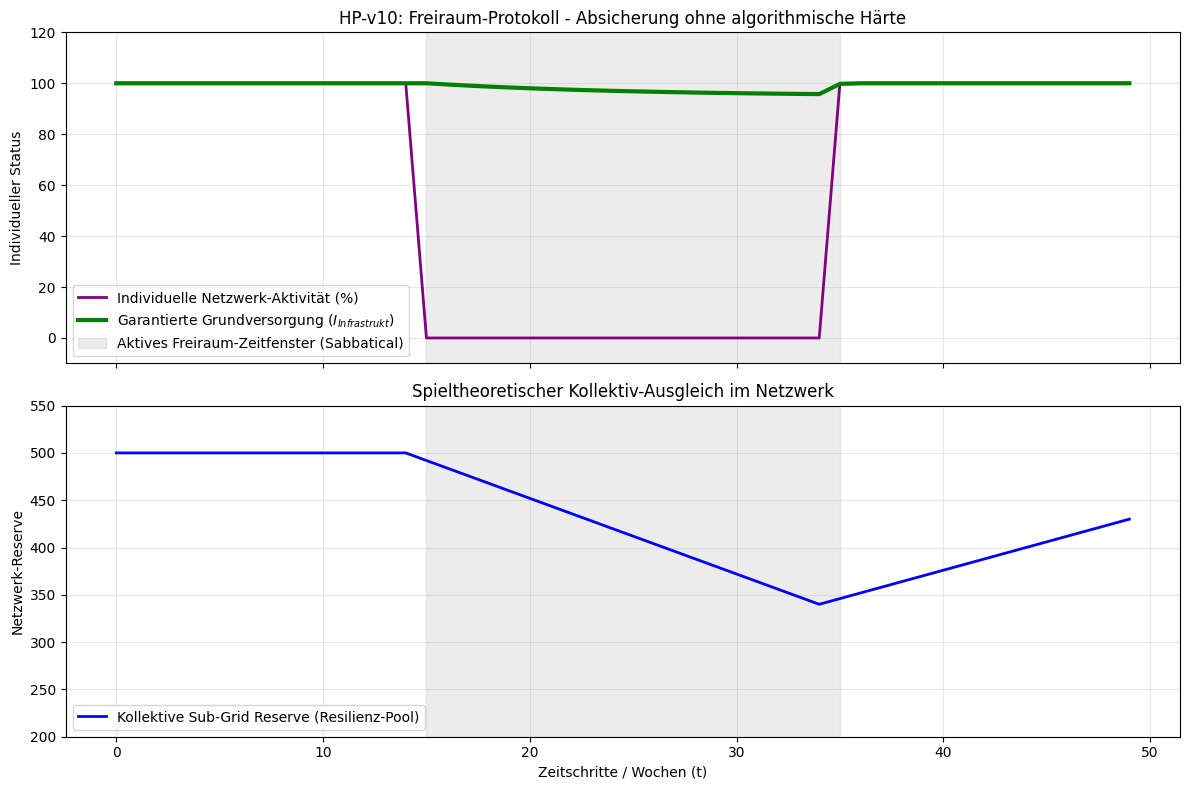

In [2]:
import numpy as np
import matplotlib.pyplot as plt

def simulate_freiraum_protocol(steps=50, sabbatical_start=15, sabbatical_end=35):
    np.random.seed(42)

    # Ressourcen- und Aktivitäts-Vektoren über die Zeit
    activity = np.ones(steps) * 100.0  # Prozentuale Beteiligung am Netzwerkkonsens
    basic_supply = np.zeros(steps)    # Bereitgestellte Grundversorgung (Energie, Wohnraum)
    subgrid_reserve = np.zeros(steps)  # Puffer-Kapazität der Gemeinschaft

    # Startwerte
    current_supply = 100.0
    current_reserve = 500.0  # Kollektiver Pool des Sub-Grids

    for t in range(steps):
        # Wenn der Nutzer im Sabbatical (Freiraum) ist, sinkt seine Aktivität auf 0
        if sabbatical_start <= t < sabbatical_end:
            activity[t] = 0.0
            # Die Grundversorgung bleibt durch Ebene-0-Invariante garantiert geschützt
            # Sie erfährt lediglich ein minimales, strukturelles Kulanzfenster-Damping
            current_supply = 100.0 - 5.0 * (1.0 - np.exp(-0.1 * (t - sabbatical_start)))
            # Das Kollektiv fängt den Ausfall auf (Reserve schrumpft temporär)
            current_reserve -= 8.0
        else:
            # Normalbetrieb: Hohe Aktivität stärkt die kollektive Reserve
            if t >= sabbatical_end:
                # Schnelle Regeneration nach Rückkehr
                activity[t] = 100.0
                current_supply = min(100.0, current_supply + 4.0)
                current_reserve = min(500.0, current_reserve + 6.0)
            else:
                activity[t] = 100.0
                current_supply = 100.0
                current_reserve = min(500.0, current_reserve + 2.0)

        basic_supply[t] = current_supply
        subgrid_reserve[t] = current_reserve

    return activity, basic_supply, subgrid_reserve

# Simulation starten
activity, supply, reserve = simulate_freiraum_protocol()

# --- DIAGRAMM ZEICHNEN ---
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# Plot 1: Individuelle Aktivität vs. Unantastbare Grundversorgung
ax1.plot(activity, label="Individuelle Netzwerk-Aktivität (%)", color="purple", linewidth=2)
ax1.plot(supply, label="Garantierte Grundversorgung ($I_{Infrastrukt}$)", color="green", linewidth=3)
ax1.axvspan(15, 35, color='gray', alpha=0.15, label="Aktives Freiraum-Zeitfenster (Sabbatical)")
ax1.set_title("HP-v10: Freiraum-Protokoll - Absicherung ohne algorithmische Härte", fontsize=12)
ax1.set_ylabel("Individueller Status", fontsize=10)
ax1.set_ylim(-10, 120)
ax1.grid(True, alpha=0.3)
ax1.legend(loc="lower left")

# Plot 2: Kollektive Pufferkapazität des Sub-Grids
ax2.plot(reserve, label="Kollektive Sub-Grid Reserve (Resilienz-Pool)", color="blue", linewidth=2)
ax2.axvspan(15, 35, color='gray', alpha=0.15)
ax2.set_title("Spieltheoretischer Kollektiv-Ausgleich im Netzwerk", fontsize=12)
ax2.set_xlabel("Zeitschritte / Wochen (t)", fontsize=10)
ax2.set_ylabel("Netzwerk-Reserve", fontsize=10)
ax2.set_ylim(200, 550)
ax2.grid(True, alpha=0.3)
ax2.legend(loc="lower left")

plt.tight_layout()
plt.show()